# Análise de desempenho: Serial vs. Paralelo

Usar o arquivo **`comparacao_geral_maior.csv`** para gerar:

- tabela consolidada com tempos;
- tabela pivô por tamanho e método;
- gráfico de tempo de execução;
- gráfico de speedup;
- gráfico de eficiência.

In [3]:
pip install pandas matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 23.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 70.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------------------- ---------- 5.2/7.1 MB 32.9 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 19.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Arquivo carregado: comparacao_serial_parallel\comparacao_geral_maior.csv


,n,m,p,tamanho,metodo,tempo_segundos,speedup,eficiencia,processos,validado_com_serial
0,120,240,120,120 x 240 x 120,Serial,1.82,1.000000,1.000000,1,True
1,120,240,120,120 x 240 x 120,Sem agrupamento,3.44,0.529070,0.132268,4,True
2,120,240,120,120 x 240 x 120,Por linha,1.15,1.582609,0.395652,4,True
3,120,240,120,120 x 240 x 120,Por blocos,0.88,2.068182,0.517045,4,True
4,180,360,180,180 x 360 x 180,Serial,6.74,1.000000,1.000000,1,True


In [ ]:
base_dir = Path("comparacao_serial_paralelo")

df_serial = pd.read_csv(base_dir / "comparacao_serial.csv")
df_paralelo = pd.read_csv(base_dir / "comparacao_paralelo.csv")

df_serial["metodo"] = "Serial"
df_paralelo["metodo"] = "Paralelo"

df = pd.concat([df_serial, df_paralelo], ignore_index=True)
df["tamanho"] = df["n"].astype(str) + " x " + df["m"].astype(str)

df

,n,m,p,tamanho,metodo,tempo_segundos,speedup,eficiencia,processos,validado_com_serial
0,120,240,120,120 x 240 x 120,Por blocos,0.88,2.068182,0.517045,4,True
1,120,240,120,120 x 240 x 120,Por linha,1.15,1.582609,0.395652,4,True
2,120,240,120,120 x 240 x 120,Sem agrupamento,3.44,0.529070,0.132268,4,True
3,120,240,120,120 x 240 x 120,Serial,1.82,1.000000,1.000000,1,True
4,180,360,180,180 x 360 x 180,Por blocos,3.21,2.099688,0.524922,4,True
5,180,360,180,180 x 360 x 180,Por linha,4.33,1.556582,0.389145,4,True
6,180,360,180,180 x 360 x 180,Sem agrupamento,12.91,0.522076,0.130519,4,True
7,180,360,180,180 x 360 x 180,Serial,6.74,1.000000,1.000000,1,True
8,240,480,240,240 x 480 x 240,Por blocos,7.03,2.264580,0.566145,4,True
9,240,480,240,240 x 480 x 240,Por linha,9.84,1.617886,0.404472,4,True


In [ ]:
tabela_tempo = df.pivot(index="tamanho", columns="metodo", values="tempo_execucao").reset_index()
tabela_tempo

metodo,Por blocos,Por linha,Sem agrupamento,Serial
tamanho,,,,
120 x 240 x 120,0.88,1.15,3.44,1.82
180 x 360 x 180,3.21,4.33,12.91,6.74
240 x 480 x 240,7.03,9.84,29.40,15.92
300 x 600 x 300,13.21,19.08,58.27,31.55


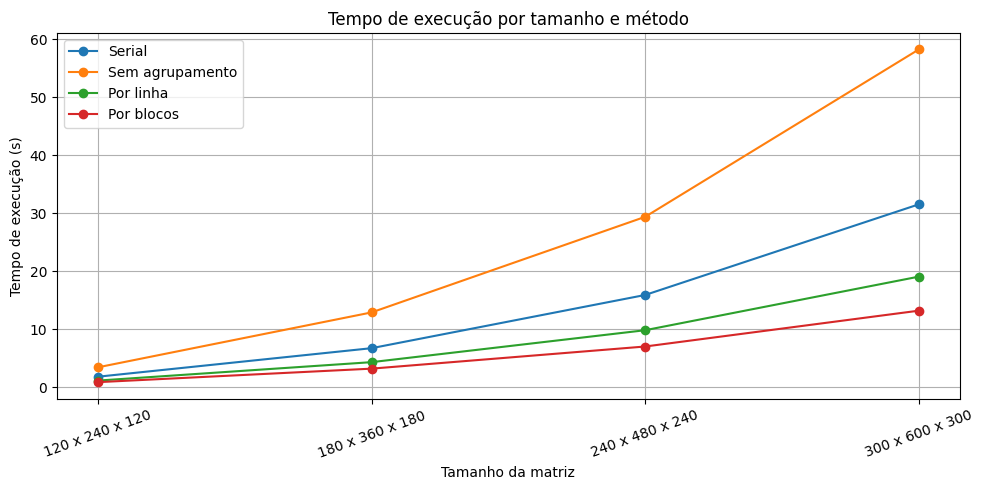

In [ ]:
df_speedup = tabela_tempo.copy()
df_speedup["speedup"] = df_speedup["Serial"] / df_speedup["Paralelo"]
df_speedup

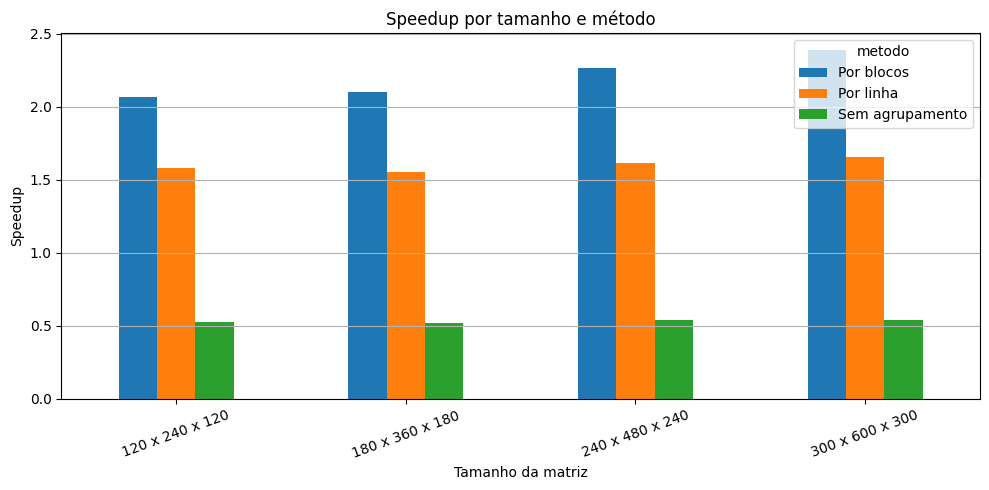

In [ ]:
plt.figure(figsize=(10, 5))

for metodo in df["metodo"].unique():
    base = df[df["metodo"] == metodo]
    plt.plot(base["tamanho"], base["tempo_execucao"], marker="o", label=metodo)

plt.title("Comparação de Tempo: Serial vs Paralelo")
plt.xlabel("Tamanho da matriz")
plt.ylabel("Tempo de execução (s)")
plt.legend()
plt.grid(True, axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

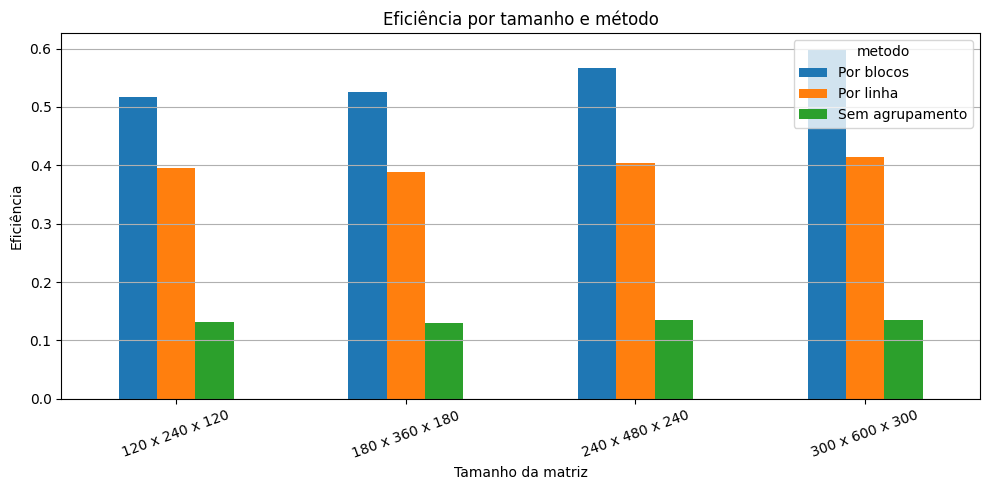

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(df_speedup["tamanho"], df_speedup["speedup"])

plt.title("Speedup por Tamanho")
plt.xlabel("Tamanho da matriz")
plt.ylabel("Speedup")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## Melhor método por tamanho

In [11]:
somente_paralelos = df[df["metodo"] != "Serial"].copy()
melhor = somente_paralelos.loc[somente_paralelos.groupby("tamanho")["tempo_segundos"].idxmin()]
melhor[["tamanho", "metodo", "tempo_segundos", "speedup", "eficiencia"]]

,tamanho,metodo,tempo_segundos,speedup,eficiencia
3,120 x 240 x 120,Por blocos,0.88,2.068182,0.517045
7,180 x 360 x 180,Por blocos,3.21,2.099688,0.524922
11,240 x 480 x 240,Por blocos,7.03,2.264580,0.566145
15,300 x 600 x 300,Por blocos,13.21,2.388342,0.597086
